<a href="https://colab.research.google.com/github/enzozavaleta/EXAMENPARCIAL/blob/main/Ejeercicio2_CodigoParte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- RESULTADOS NUMÉRICOS PARTE 2 ---
f = 10.0 kHz -> Progresiva O2: 0.0264 | Spline: 0.0270
f = 40.0 kHz -> Centrada O2:   -0.0718 | Centrada O4: -0.0726 | Spline: -0.0769
f = 70.0 kHz -> Centrada O2:   0.0444 | Centrada O4: 0.0447 | Spline: 0.0447
f = 100.0 kHz -> Centrada O2:  0.0120 | Centrada O4: 0.0119 | Spline: 0.0118



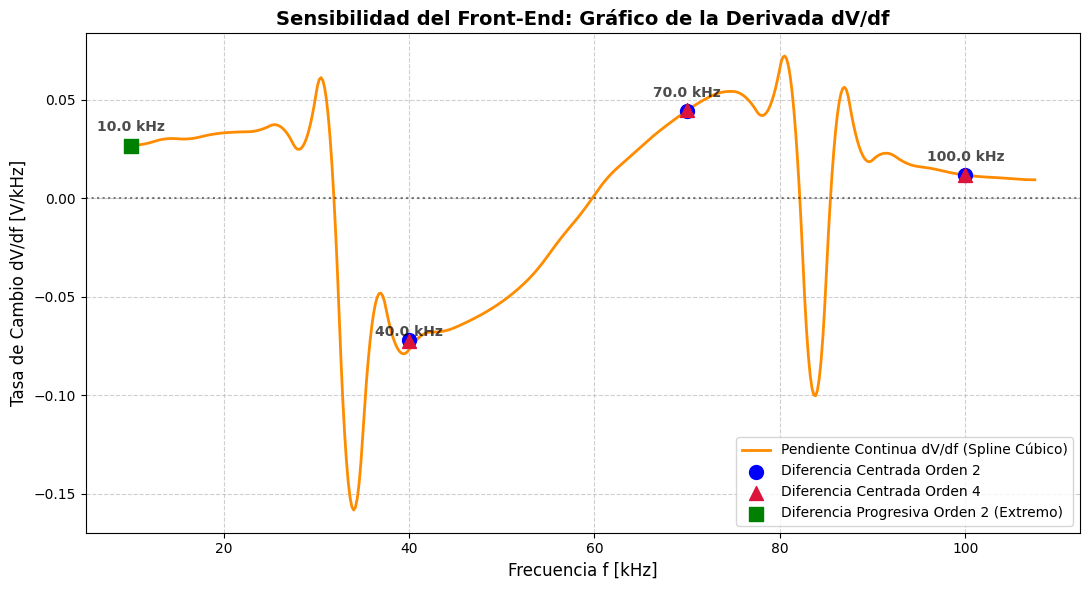

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# 1. Definición de los datos del ensayo (proporcionados en el examen)
f = np.array([
    10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0,
    52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5,
    95.0, 97.5, 100.0, 102.5, 105.0, 107.5
])

V = np.array([
    0.842, 0.911, 0.986, 1.062, 1.143, 1.227, 1.314, 1.401, 1.482, 1.551, 1.216, 1.048, 0.866, 0.689, 0.521,
    0.364, 0.223, 0.103, 0.012, -0.041, -0.057, -0.034, 0.018, 0.096, 0.197, 0.318, 0.452, 0.579, 0.700,
    0.809, 0.611, 0.688, 0.756, 0.811, 0.856, 0.894, 0.926, 0.954, 0.980, 1.004
])

# 2. Funciones de derivación numérica discretas
h = 2.5  # Paso constante en kHz

def diff_central_2(V_arr, idx, h):
    return (V_arr[idx+1] - V_arr[idx-1]) / (2 * h)

def diff_central_4(V_arr, idx, h):
    return (-V_arr[idx+2] + 8*V_arr[idx+1] - 8*V_arr[idx-1] + V_arr[idx-2]) / (12 * h)

def diff_prog_2(V_arr, idx, h):
    return (-3*V_arr[idx] + 4*V_arr[idx+1] - V_arr[idx+2]) / (2 * h)

# 3. Ajuste del Spline Cúbico Natural para derivación continua
cs_V = CubicSpline(f, V, bc_type='natural')

# Mapeo de índices de la tabla para las frecuencias solicitadas
# f=10.0 -> idx=0 || f=40.0 -> idx=12 || f=70.0 -> idx=24 || f=100.0 -> idx=36
idx_40, idx_70, idx_100 = 12, 24, 36

# Almacenar los cálculos puntuales para la impresión y el gráfico
f_puntos = np.array([10.0, 40.0, 70.0, 100.0])
derivadas_c2 = np.array([np.nan, diff_central_2(V, idx_40, h), diff_central_2(V, idx_70, h), diff_central_2(V, idx_100, h)])
derivadas_c4 = np.array([np.nan, diff_central_4(V, idx_40, h), diff_central_4(V, idx_70, h), diff_central_4(V, idx_100, h)])
derivadas_prog2 = np.array([diff_prog_2(V, 0, h), np.nan, np.nan, np.nan])
derivadas_spline = cs_V(f_puntos, nu=1)  # nu=1 calcula de forma directa la primera derivada

# --- IMPRESIÓN DE RESULTADOS EN CONSOLA ---
print("--- RESULTADOS NUMÉRICOS PARTE 2 ---")
print(f"f = 10.0 kHz -> Progresiva O2: {derivadas_prog2[0]:.4f} | Spline: {derivadas_spline[0]:.4f}")
print(f"f = 40.0 kHz -> Centrada O2:   {derivadas_c2[1]:.4f} | Centrada O4: {derivadas_c4[1]:.4f} | Spline: {derivadas_spline[1]:.4f}")
print(f"f = 70.0 kHz -> Centrada O2:   {derivadas_c2[2]:.4f} | Centrada O4: {derivadas_c4[2]:.4f} | Spline: {derivadas_spline[2]:.4f}")
print(f"f = 100.0 kHz -> Centrada O2:  {derivadas_c2[3]:.4f} | Centrada O4: {derivadas_c4[3]:.4f} | Spline: {derivadas_spline[3]:.4f}\n")

# --- GENERACIÓN DE GRÁFICOS ---
f_smooth = np.linspace(f.min(), f.max(), 500)
# Evaluamos la primera derivada del spline en todo el espectro continuo
dv_df_smooth = cs_V(f_smooth, nu=1)

plt.figure(figsize=(11, 6))

# Graficar el comportamiento continuo de la derivada teórica/spline
plt.plot(f_smooth, dv_df_smooth, label="Pendiente Continua dV/df (Spline Cúbico)", color="darkorange", linewidth=2)
plt.axhline(0, color="black", linestyle=":", alpha=0.5)  # Línea de referencia en cero cambio

# Graficar las aproximaciones numéricas puntuales calculadas por fórmulas discretas
plt.scatter(f_puntos[1:], derivadas_c2[1:], color="blue", marker="o", s=100, label="Diferencia Centrada Orden 2", zorder=3)
plt.scatter(f_puntos[1:], derivadas_c4[1:], color="crimson", marker="^", s=100, label="Diferencia Centrada Orden 4", zorder=3)
plt.scatter(f_puntos[0], derivadas_prog2[0], color="green", marker="s", s=100, label="Diferencia Progresiva Orden 2 (Extremo)", zorder=3)

# Ajustes de diseño de la gráfica
plt.title("Sensibilidad del Front-End: Gráfico de la Derivada dV/df", fontsize=14, fontweight='bold')
plt.xlabel("Frecuencia f [kHz]", fontsize=12)
plt.ylabel("Tasa de Cambio dV/df [V/kHz]", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower right", fontsize=10)

# Resaltar visualmente las zonas analizadas con anotaciones de texto básicas
for i, txt in enumerate(["10.0 kHz", "40.0 kHz", "70.0 kHz", "100.0 kHz"]):
    plt.annotate(txt, (f_puntos[i], derivadas_spline[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.show()
